# BOLERO
## From diagnostic evidence to the actual layered reconstruction system

This notebook is the beginning of the **Bolero program itself**.

The first section preserves the large diagnostic evidence we already generated. It builds:

1. a multiclass confusion matrix,
2. one-vs-rest positive/negative relations for every class,
3. gain/loss relations across transformations,
4. a large multi-entity graph connecting classes, methods, gains, losses and prediction transitions.

Then we move into the actual Bolero construction pipeline:

**image → relative depth → spatial layers → displaced layers → reconstructed/parallax view**

The final cell is deliberately a visualization infodump. It is meant to be visually excessive and useful for exploration rather than publication.


In [71]:
# ============================================================
# BOLERO
# Cell 1: Imports, declarations, paths, and initialization
# ============================================================

from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageDraw

import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"F:\DeepLearningTest\bolero_repo"
)

DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SRC_DIR = PROJECT_ROOT / "src"
RESULTS_DIR = PROJECT_ROOT / "results"

DEPTH_MAP_DIR = RESULTS_DIR / "depth_maps"
LAYERS_DIR = RESULTS_DIR / "layers"
ABLATIONS_DIR = RESULTS_DIR / "ablations"
PARALLAX_DIR = RESULTS_DIR / "parallax"
ANALYSIS_DIR = RESULTS_DIR / "analysis"

# ------------------------------------------------------------
# Create directories
# ------------------------------------------------------------

for directory in [
    DATA_DIR,
    NOTEBOOK_DIR,
    SRC_DIR,
    RESULTS_DIR,
    DEPTH_MAP_DIR,
    LAYERS_DIR,
    ABLATIONS_DIR,
    PARALLAX_DIR,
    ANALYSIS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

# ------------------------------------------------------------
# Diagnostic evidence
# ------------------------------------------------------------

DIAGNOSTIC_DIR = (
    RESULTS_DIR / "analysis" / "comprehensive_diagnostic"
)

PREDICTION_RECORDS_FILE = (
    DIAGNOSTIC_DIR / "all_prediction_records.csv"
)

HEATMAP_RECORDS_FILE = (
    DIAGNOSTIC_DIR / "heatmap_region_records.csv"
)

METHOD_SUMMARY_FILE = (
    DIAGNOSTIC_DIR / "method_summary.csv"
)

STRENGTH_CURVES_FILE = (
    DIAGNOSTIC_DIR / "strength_curves.csv"
)

CYCLE_SUMMARY_FILE = (
    DIAGNOSTIC_DIR / "cycle_summary.csv"
)

CROSS_CYCLE_FILE = (
    DIAGNOSTIC_DIR / "cross_cycle_stability.csv"
)

HEATMAP_SUMMARY_FILE = (
    DIAGNOSTIC_DIR / "heatmap_region_summary.csv"
)

# ------------------------------------------------------------
# Model / device configuration
# ------------------------------------------------------------

DEVICE = torch.device("cpu")

DEPTH_MODEL_NAME = (
    "depth-anything/Depth-Anything-V2-Small-hf"
)

# ------------------------------------------------------------
# Image configuration
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".JPG",
    ".JPEG",
    ".PNG",
}

CONTROLLED_N = 100

# ------------------------------------------------------------
# Imagenette class mapping
# ------------------------------------------------------------

IMAGENETTE_CLASSES = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

CLASS_IDS = list(IMAGENETTE_CLASSES.keys())

CLASS_NAMES = list(IMAGENETTE_CLASSES.values())

# ------------------------------------------------------------
# Analysis configuration
# ------------------------------------------------------------

TRUE_COL = "true_class"
ORIGINAL_PRED_COL = "original_prediction"
TRANSFORMED_PRED_COL = "transformed_prediction"

METHOD_COL = "method"
CYCLE_COL = "cycle"

CONF_ORIGINAL_COL = "original_confidence"
CONF_TRANSFORMED_COL = "transformed_confidence"

IMAGE_COL = "image_path"

# ------------------------------------------------------------
# Working dataframe declarations
#
# These are deliberately initialized here so that later cells
# never depend on an undefined variable.
# ------------------------------------------------------------

prediction_records = None
analysis_records = None

heatmap_records = None
method_summary = None
strength_curves = None
cycle_summary = None
cross_cycle_stability = None
heatmap_region_summary = None

# ------------------------------------------------------------
# Basic environment report
# ------------------------------------------------------------

print("=" * 70)
print("BOLERO INITIALIZATION")
print("=" * 70)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nDiagnostic evidence:")
print(PREDICTION_RECORDS_FILE)

print("\nDiagnostic file exists:")
print(PREDICTION_RECORDS_FILE.exists())

print("\nDevice:")
print(DEVICE)

print("\nDepth model:")
print(DEPTH_MODEL_NAME)

print("\nClasses:")
for class_id, class_name in IMAGENETTE_CLASSES.items():
    print(f"  {class_id} -> {class_name}")

print("\nDeclared dataframe objects:")
print("  prediction_records =", prediction_records)
print("  analysis_records   =", analysis_records)

print("\n✓ Bolero initialization complete.")

BOLERO INITIALIZATION

Project root:
F:\DeepLearningTest\bolero_repo

Diagnostic evidence:
F:\DeepLearningTest\bolero_repo\results\analysis\comprehensive_diagnostic\all_prediction_records.csv

Diagnostic file exists:
True

Device:
cpu

Depth model:
depth-anything/Depth-Anything-V2-Small-hf

Classes:
  n01440764 -> tench
  n02102040 -> English springer
  n02979186 -> cassette player
  n03000684 -> chain saw
  n03028079 -> church
  n03394916 -> French horn
  n03417042 -> garbage truck
  n03425413 -> gas pump
  n03445777 -> golf ball
  n03888257 -> parachute

Declared dataframe objects:
  prediction_records = None
  analysis_records   = None

✓ Bolero initialization complete.


In [72]:
# ============================================================
# BOLERO
# Cell 2: Load diagnostic evidence
# ============================================================

print("=" * 70)
print("LOADING BOLERO DIAGNOSTIC EVIDENCE")
print("=" * 70)

if not PREDICTION_RECORDS_FILE.exists():
    raise FileNotFoundError(
        f"Diagnostic file not found:\n{PREDICTION_RECORDS_FILE}"
    )

prediction_records = pd.read_csv(
    PREDICTION_RECORDS_FILE
)

print("\nFile:")
print(PREDICTION_RECORDS_FILE)

print("\nRows:")
print(len(prediction_records))

print("\nColumns:")
for column in prediction_records.columns:
    print(f"  {column}")

print("\nShape:")
print(prediction_records.shape)

print("\n✓ Diagnostic evidence loaded into prediction_records.")

LOADING BOLERO DIAGNOSTIC EVIDENCE

File:
F:\DeepLearningTest\bolero_repo\results\analysis\comprehensive_diagnostic\all_prediction_records.csv

Rows:
122450

Columns:
  cycle
  image_index
  image_path
  class_id
  true_class
  family
  method
  parameter
  original_prediction
  transformed_prediction
  original_confidence
  transformed_confidence
  correct
  transformed_correct
  prediction_changed
  confidence_change
  region_count
  region_rank
  region_id
  region_coverage
  region_depth
  transition
  absolute_confidence_change

Shape:
(122450, 23)

✓ Diagnostic evidence loaded into prediction_records.


In [73]:
# ============================================================
# BOLERO
# Cell 3: Create normalized analysis records
# ============================================================

print("=" * 70)
print("CREATING NORMALIZED ANALYSIS RECORDS")
print("=" * 70)

if prediction_records is None:
    raise RuntimeError(
        "prediction_records is empty. "
        "Run Cell 2 first."
    )

required_columns = [
    TRUE_COL,
    ORIGINAL_PRED_COL,
    TRANSFORMED_PRED_COL,
    METHOD_COL,
    CYCLE_COL,
    CONF_ORIGINAL_COL,
    CONF_TRANSFORMED_COL,
    IMAGE_COL,
]

missing_columns = [
    column
    for column in required_columns
    if column not in prediction_records.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns:\n"
        + "\n".join(
            f"  - {column}"
            for column in missing_columns
        )
    )

analysis_records = prediction_records.copy()

# ------------------------------------------------------------
# Class identifiers
# ------------------------------------------------------------

analysis_records["true_class_id"] = (
    analysis_records[TRUE_COL]
    .astype(str)
)

analysis_records["original_prediction_id"] = (
    analysis_records[ORIGINAL_PRED_COL]
    .astype(str)
)

analysis_records["transformed_prediction_id"] = (
    analysis_records[TRANSFORMED_PRED_COL]
    .astype(str)
)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

analysis_records["true_class_name"] = (
    analysis_records["true_class_id"]
    .map(IMAGENETTE_CLASSES)
    .fillna(analysis_records["true_class_id"])
)

analysis_records["original_prediction_name"] = (
    analysis_records["original_prediction_id"]
    .map(IMAGENETTE_CLASSES)
    .fillna(
        analysis_records["original_prediction_id"]
    )
)

analysis_records["transformed_prediction_name"] = (
    analysis_records["transformed_prediction_id"]
    .map(IMAGENETTE_CLASSES)
    .fillna(
        analysis_records["transformed_prediction_id"]
    )
)

# ------------------------------------------------------------
# Correctness
# ------------------------------------------------------------

analysis_records["original_correct"] = (
    analysis_records["original_prediction_id"]
    ==
    analysis_records["true_class_id"]
)

analysis_records["transformed_correct"] = (
    analysis_records["transformed_prediction_id"]
    ==
    analysis_records["true_class_id"]
)

analysis_records["prediction_changed"] = (
    analysis_records["original_prediction_id"]
    !=
    analysis_records["transformed_prediction_id"]
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

analysis_records["original_confidence_value"] = (
    pd.to_numeric(
        analysis_records[CONF_ORIGINAL_COL],
        errors="coerce",
    )
)

analysis_records["transformed_confidence_value"] = (
    pd.to_numeric(
        analysis_records[CONF_TRANSFORMED_COL],
        errors="coerce",
    )
)

# ------------------------------------------------------------
# Convenience columns
# ------------------------------------------------------------

analysis_records["method_name"] = (
    analysis_records[METHOD_COL]
    .astype(str)
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nAnalysis records:")
print(len(analysis_records))

print("\nAnalysis shape:")
print(analysis_records.shape)

print("\nMethods:")
print(
    analysis_records["method_name"]
    .value_counts()
    .to_string()
)

print("\nOriginal correctness:")
print(
    f"{analysis_records['original_correct'].mean():.2%}"
)

print("\nTransformed correctness:")
print(
    f"{analysis_records['transformed_correct'].mean():.2%}"
)

print("\nPrediction changes:")
print(
    f"{analysis_records['prediction_changed'].mean():.2%}"
)

print("\n✓ analysis_records initialized successfully.")

CREATING NORMALIZED ANALYSIS RECORDS

Analysis records:
122450

Analysis shape:
(122450, 33)

Methods:
method_name
region_remove          37650
region_soft            37650
region_isolate         37650
hard_removal            2500
soft_attenuation        2500
inverted                 500
grayscale                500
contrast_enhanced        500
brightness_enhanced      500
boundary_enhanced        500
boundary_suppressed      500
high_depth_only          500
middle_depth_only        500
low_depth_only           500

Original correctness:
14.76%

Transformed correctness:
11.55%

Prediction changes:
32.18%

✓ analysis_records initialized successfully.


## Diagnostic evidence: positive and negative class relations

A normal confusion matrix only tells us where predictions landed.

For Bolero we also want the **one-vs-rest relationship** of every class:

- **TP**: the class was present and recognized as itself.
- **FP**: another class was incorrectly assigned to this class.
- **FN**: this class was present but assigned elsewhere.
- **TN**: neither the true class nor the predicted class was this class.

This gives every category a positive and negative relationship with the complete prediction system.


In [74]:
# ============================================================
# BOLERO
# Cell 4: Confusion matrix and positive/negative relations
# ============================================================

print("=" * 70)
print("BOLERO - CONFUSION MATRIX AND CLASS RELATIONS")
print("=" * 70)

# ------------------------------------------------------------
# Initialization check
# ------------------------------------------------------------

if "analysis_records" not in globals():
    raise RuntimeError(
        "analysis_records has not been initialized. "
        "Run Cells 1, 2, and 3 first."
    )

if analysis_records is None:
    raise RuntimeError(
        "analysis_records is None. "
        "Run Cell 3 first."
    )

records = analysis_records.copy()

print("\nRecords available:")
print(len(records))

# ------------------------------------------------------------
# Confusion matrix
#
# The original prediction is the baseline prediction already
# stored in every diagnostic record.
# ------------------------------------------------------------

confusion_matrix = pd.crosstab(
    records["true_class_name"],
    records["original_prediction_name"],
)

confusion_matrix = confusion_matrix.reindex(
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
    fill_value=0,
)

# ------------------------------------------------------------
# Per-class positive / negative relations
#
# Positive:
#   True class = X AND predicted class = X
#
# False positive:
#   Predicted as X, but true class is something else
#
# False negative:
#   True class is X, but predicted as something else
#
# True negative:
#   Neither true nor predicted class is X
# ------------------------------------------------------------

positive_negative = []

total_records = len(records)

for class_name in CLASS_NAMES:

    true_positive = int(
        (
            (records["true_class_name"] == class_name)
            &
            (records["original_prediction_name"] == class_name)
        ).sum()
    )

    false_positive = int(
        (
            (records["true_class_name"] != class_name)
            &
            (records["original_prediction_name"] == class_name)
        ).sum()
    )

    false_negative = int(
        (
            (records["true_class_name"] == class_name)
            &
            (records["original_prediction_name"] != class_name)
        ).sum()
    )

    true_negative = int(
        (
            (records["true_class_name"] != class_name)
            &
            (records["original_prediction_name"] != class_name)
        ).sum()
    )

    precision = (
        true_positive
        /
        (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0
    )

    recall = (
        true_positive
        /
        (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0
    )

    positive_rate = (
        (true_positive + false_positive)
        /
        total_records
    )

    negative_relation_rate = (
        (true_negative + false_negative)
        /
        total_records
    )

    positive_negative.append(
        {
            "class_name": class_name,
            "true_positive": true_positive,
            "false_positive": false_positive,
            "false_negative": false_negative,
            "true_negative": true_negative,
            "precision": precision,
            "recall": recall,
            "positive_prediction_rate": positive_rate,
            "negative_relation_rate": negative_relation_rate,
        }
    )

positive_negative_relations = pd.DataFrame(
    positive_negative
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

confusion_matrix.to_csv(
    ANALYSIS_DIR /
    "bolero_original_confusion_matrix.csv"
)

positive_negative_relations.to_csv(
    ANALYSIS_DIR /
    "bolero_positive_negative_relations.csv",
    index=False,
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nOriginal confusion matrix:")
print(confusion_matrix)

print("\nPositive / negative class relations:")

print(
    positive_negative_relations.to_string(
        index=False,
        formatters={
            "precision": "{:.2%}".format,
            "recall": "{:.2%}".format,
            "positive_prediction_rate": "{:.2%}".format,
            "negative_relation_rate": "{:.2%}".format,
        },
    )
)

print("\n✓ Confusion matrix created.")
print("✓ Positive/negative relations created.")

BOLERO - CONFUSION MATRIX AND CLASS RELATIONS

Records available:
122450

Original confusion matrix:
original_prediction_name  tench  English springer  cassette player  chain saw  \
true_class_name                                                                 
tench                         0                 0                0          0   
English springer              0                 0                0          0   
cassette player               0                 0             5950          0   
chain saw                     0                 0                0          0   
church                        0                 0                0          0   
French horn                   0                 0                0          0   
garbage truck                 0                 0                0          0   
gas pump                      0                 0                0          0   
golf ball                     0                 0                0          0   
parachut

In [75]:
# ============================================================
# BOLERO
# Cell 5: Growth and loss relations
# ============================================================

print("=" * 70)
print("BOLERO - GROWTH AND LOSS RELATIONS")
print("=" * 70)

if analysis_records is None:
    raise RuntimeError(
        "analysis_records is not initialized. "
        "Run Cells 1, 2, and 3 first."
    )

records = analysis_records.copy()

# ------------------------------------------------------------
# Inspect the actual class representation
# ------------------------------------------------------------

print("\nTrue class values:")
print(
    records["true_class_id"]
    .value_counts()
    .head(20)
    .to_string()
)

print("\nTrue class names:")
print(
    records["true_class_name"]
    .value_counts()
    .head(20)
    .to_string()
)

# ------------------------------------------------------------
# Determine which class representation is actually present
# ------------------------------------------------------------

available_ids = set(
    records["true_class_id"]
    .dropna()
    .astype(str)
    .unique()
)

available_names = set(
    records["true_class_name"]
    .dropna()
    .astype(str)
    .unique()
)

if set(CLASS_IDS).intersection(available_ids):
    CLASS_COLUMN = "true_class_id"
    CLASS_LOOKUP = IMAGENETTE_CLASSES

elif set(CLASS_NAMES).intersection(available_names):
    CLASS_COLUMN = "true_class_name"
    CLASS_LOOKUP = {
        name: name
        for name in CLASS_NAMES
    }

else:
    raise ValueError(
        "Could not match the dataset's true-class values "
        "to the declared Imagenette classes.\n\n"
        "Dataset values:\n"
        + "\n".join(
            sorted(
                map(str, available_ids)
            )[:30]
        )
    )

print("\nUsing class column:")
print(CLASS_COLUMN)

# ------------------------------------------------------------
# Class-level growth / loss
# ------------------------------------------------------------

class_relations_list = []

for class_value, class_name in CLASS_LOOKUP.items():

    class_records = records[
        records[CLASS_COLUMN].astype(str)
        == str(class_value)
    ]

    if class_records.empty:
        continue

    original_correct = int(
        class_records["original_correct"].sum()
    )

    transformed_correct = int(
        class_records["transformed_correct"].sum()
    )

    total = len(class_records)

    correct_gain = (
        transformed_correct
        - original_correct
    )

    growth_rate = (
        max(correct_gain, 0) / total
    )

    loss_rate = (
        max(-correct_gain, 0) / total
    )

    class_relations_list.append(
        {
            "class_name": class_name,
            "records": total,
            "original_correct": original_correct,
            "transformed_correct": transformed_correct,
            "correct_gain": correct_gain,
            "growth_rate": growth_rate,
            "loss_rate": loss_rate,
        }
    )

class_relations = pd.DataFrame(
    class_relations_list,
    columns=[
        "class_name",
        "records",
        "original_correct",
        "transformed_correct",
        "correct_gain",
        "growth_rate",
        "loss_rate",
    ],
)

# ------------------------------------------------------------
# Prediction-to-prediction transitions
# ------------------------------------------------------------

transition_relations = (
    records
    .groupby(
        [
            "original_prediction_name",
            "transformed_prediction_name",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="count")
)

transition_relations["rate"] = (
    transition_relations["count"]
    / len(records)
)

transition_relations = (
    transition_relations
    .sort_values(
        "count",
        ascending=False,
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Correctness transitions
# ------------------------------------------------------------

correctness_relations = (
    records
    .groupby(
        [
            "original_correct",
            "transformed_correct",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="count")
)

correctness_relations["rate"] = (
    correctness_relations["count"]
    / len(records)
)

def transition_name(row):
    if row["original_correct"] and row["transformed_correct"]:
        return "Correct → Correct"

    if row["original_correct"] and not row["transformed_correct"]:
        return "Correct → Wrong"

    if not row["original_correct"] and row["transformed_correct"]:
        return "Wrong → Correct"

    return "Wrong → Wrong"

correctness_relations["transition"] = (
    correctness_relations
    .apply(
        transition_name,
        axis=1,
    )
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

class_relations.to_csv(
    ANALYSIS_DIR /
    "bolero_class_growth_loss_relations.csv",
    index=False,
)

transition_relations.to_csv(
    ANALYSIS_DIR /
    "bolero_prediction_transition_relations.csv",
    index=False,
)

correctness_relations.to_csv(
    ANALYSIS_DIR /
    "bolero_correctness_transition_relations.csv",
    index=False,
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nClass growth/loss:")
print(
    class_relations.to_string(
        index=False
    )
)

print("\nTop prediction transitions:")
print(
    transition_relations.head(20).to_string(
        index=False
    )
)

print("\nCorrectness transitions:")
print(
    correctness_relations[
        [
            "transition",
            "count",
            "rate",
        ]
    ].to_string(index=False)
)

print("\n✓ Growth and loss relations created.")

BOLERO - GROWTH AND LOSS RELATIONS

True class values:
true_class_id
French horn         12875
chain saw           12650
church              12275
gas pump            12275
tench               12200
cassette player     12200
golf ball           12125
garbage truck       12050
English springer    11900
parachute           11900

True class names:
true_class_name
French horn         12875
chain saw           12650
church              12275
gas pump            12275
tench               12200
cassette player     12200
golf ball           12125
garbage truck       12050
English springer    11900
parachute           11900

Using class column:
true_class_name

Class growth/loss:
      class_name  records  original_correct  transformed_correct  correct_gain  growth_rate  loss_rate
           tench    12200                 0                    0             0          0.0   0.000000
English springer    11900                 0                    0             0          0.0   0.000000
 cassette 

## The large graph

This graph treats the diagnostic study as a **network of entities rather than a table**.

Nodes represent:

- image classes,
- transformation methods,
- correct recognition,
- prediction change,
- gains,
- losses.

Edges represent relationships such as:

**method → class → gain/loss → prediction behavior**

The purpose is not to make a clean publication figure. It is an information-dense map of what happened during the study.


In [76]:
# ============================================================
# BOLERO
# Cell 6: Growth and loss analysis
# ============================================================

print("=" * 70)
print("BOLERO - CLASS GROWTH AND LOSS")
print("=" * 70)

# ------------------------------------------------------------
# Check that Cell 5 produced the required dataframe
# ------------------------------------------------------------

if "class_relations" not in globals():
    raise RuntimeError(
        "class_relations has not been created. "
        "Run Cell 5 first."
    )

growth_loss = class_relations.copy()

# ------------------------------------------------------------
# Calculate net movement
# ------------------------------------------------------------

growth_loss["net_change"] = (
    growth_loss["transformed_correct"]
    -
    growth_loss["original_correct"]
)

growth_loss["absolute_change"] = (
    growth_loss["net_change"].abs()
)

# ------------------------------------------------------------
# Class-level rates
# ------------------------------------------------------------

growth_loss["original_accuracy"] = (
    growth_loss["original_correct"]
    /
    growth_loss["records"]
)

growth_loss["transformed_accuracy"] = (
    growth_loss["transformed_correct"]
    /
    growth_loss["records"]
)

growth_loss["accuracy_change"] = (
    growth_loss["transformed_accuracy"]
    -
    growth_loss["original_accuracy"]
)

# ------------------------------------------------------------
# Classification of movement
# ------------------------------------------------------------

def movement_label(change):

    if change > 0:
        return "Growth"

    if change < 0:
        return "Loss"

    return "Stable"


growth_loss["movement"] = (
    growth_loss["net_change"]
    .apply(movement_label)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

growth_loss.to_csv(
    ANALYSIS_DIR /
    "bolero_growth_loss_analysis.csv",
    index=False,
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_columns = [
    "class_name",
    "records",
    "original_correct",
    "transformed_correct",
    "net_change",
    "original_accuracy",
    "transformed_accuracy",
    "accuracy_change",
    "movement",
]

print("\nClass-level movement:\n")

print(
    growth_loss[
        display_columns
    ].to_string(
        index=False,
        formatters={
            "original_accuracy": "{:.2%}".format,
            "transformed_accuracy": "{:.2%}".format,
            "accuracy_change": "{:+.2%}".format,
        },
    )
)

print("\nMovement counts:")
print(
    growth_loss["movement"]
    .value_counts()
    .to_string()
)

print("\nTotal positive movement:")
print(
    growth_loss.loc[
        growth_loss["net_change"] > 0,
        "net_change"
    ].sum()
)

print("\nTotal negative movement:")
print(
    growth_loss.loc[
        growth_loss["net_change"] < 0,
        "net_change"
    ].sum()
)

print("\n✓ Growth/loss analysis created.")

BOLERO - CLASS GROWTH AND LOSS

Class-level movement:

      class_name  records  original_correct  transformed_correct  net_change original_accuracy transformed_accuracy accuracy_change movement
           tench    12200                 0                    0           0             0.00%                0.00%          +0.00%   Stable
English springer    11900                 0                    0           0             0.00%                0.00%          +0.00%   Stable
 cassette player    12200              5950                 4690       -1260            48.77%               38.44%         -10.33%     Loss
       chain saw    12650                 0                    0           0             0.00%                0.00%          +0.00%   Stable
          church    12275                 0                    0           0             0.00%                0.00%          +0.00%   Stable
     French horn    12875                 0                    0           0             0.00%     

# Begin the actual Bolero construction

The diagnostics tell us enough to stop treating this as a segmentation contest.

The construction will use the useful pieces we discovered:

- **Depth Anything V2** for a relative depth field.
- **smoothed depth** for structural stability.
- **spatially coherent depth regions** rather than arbitrary pixels.
- **boundary information** as a supporting signal.
- **soft layer manipulation** rather than aggressive gray masking.
- **layer displacement** to create artificial parallax.
- **recomposition** to test whether the visual message survives.

We deliberately keep the first construction version lightweight enough to run on the existing CPU environment.


In [77]:
# ============================================================
# BOLERO
# Cell 7: Large multi-entity growth / loss graph
# ============================================================

print("=" * 70)
print("BOLERO - MULTI-ENTITY RELATION GRAPH")
print("=" * 70)

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------

if "analysis_records" not in globals():
    raise RuntimeError(
        "analysis_records has not been initialized. "
        "Run Cells 1, 2, and 3 first."
    )

if analysis_records is None:
    raise RuntimeError(
        "analysis_records is None. "
        "Run Cell 3 first."
    )

records = analysis_records.copy()

# ------------------------------------------------------------
# Build graph data from the actual diagnostic records
# ------------------------------------------------------------

graph_edges = []

# ------------------------------------------------------------
# 1. TRUE CLASS → ORIGINAL PREDICTION
#
# Shows the baseline confusion relationships.
# ------------------------------------------------------------

baseline_relations = (
    records
    .groupby(
        [
            "true_class_name",
            "original_prediction_name",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="weight")
)

for _, row in baseline_relations.iterrows():

    graph_edges.append(
        {
            "source": f"TRUE | {row['true_class_name']}",
            "target": f"ORIGINAL | {row['original_prediction_name']}",
            "relation": "baseline prediction",
            "weight": int(row["weight"]),
        }
    )

# ------------------------------------------------------------
# 2. ORIGINAL PREDICTION → TRANSFORMED PREDICTION
#
# Shows how transformations move predictions.
# ------------------------------------------------------------

prediction_relations = (
    records
    .groupby(
        [
            "original_prediction_name",
            "transformed_prediction_name",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="weight")
)

for _, row in prediction_relations.iterrows():

    graph_edges.append(
        {
            "source": (
                f"ORIGINAL | "
                f"{row['original_prediction_name']}"
            ),
            "target": (
                f"TRANSFORMED | "
                f"{row['transformed_prediction_name']}"
            ),
            "relation": "prediction movement",
            "weight": int(row["weight"]),
        }
    )

# ------------------------------------------------------------
# 3. METHOD → TRANSFORMED PREDICTION
#
# Shows which methods generate prediction movement.
# ------------------------------------------------------------

method_relations = (
    records
    .groupby(
        [
            "method_name",
            "transformed_prediction_name",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="weight")
)

for _, row in method_relations.iterrows():

    graph_edges.append(
        {
            "source": (
                f"METHOD | "
                f"{row['method_name']}"
            ),
            "target": (
                f"TRANSFORMED | "
                f"{row['transformed_prediction_name']}"
            ),
            "relation": "method output",
            "weight": int(row["weight"]),
        }
    )

# ------------------------------------------------------------
# 4. TRUE CLASS → TRANSITION
#
# Shows whether each class tends toward preservation or loss.
# ------------------------------------------------------------

transition_relations = (
    records
    .groupby(
        [
            "true_class_name",
            "transition",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="weight")
)

for _, row in transition_relations.iterrows():

    graph_edges.append(
        {
            "source": (
                f"CLASS | "
                f"{row['true_class_name']}"
            ),
            "target": (
                f"TRANSITION | "
                f"{row['transition']}"
            ),
            "relation": "correctness transition",
            "weight": int(row["weight"]),
        }
    )

# ------------------------------------------------------------
# Convert to dataframe
# ------------------------------------------------------------

graph_edges = pd.DataFrame(
    graph_edges
)

# ------------------------------------------------------------
# Aggregate identical edges
# ------------------------------------------------------------

graph_edges = (
    graph_edges
    .groupby(
        [
            "source",
            "target",
            "relation",
        ],
        as_index=False,
    )["weight"]
    .sum()
)

# ------------------------------------------------------------
# Node table
# ------------------------------------------------------------

source_nodes = graph_edges[
    ["source"]
].rename(
    columns={"source": "node"}
)

target_nodes = graph_edges[
    ["target"]
].rename(
    columns={"target": "node"}
)

nodes = pd.concat(
    [
        source_nodes,
        target_nodes,
    ],
    ignore_index=True,
).drop_duplicates()

nodes["node_type"] = (
    nodes["node"]
    .str.split("|")
    .str[0]
    .str.strip()
)

nodes["node_name"] = (
    nodes["node"]
    .str.split("|", n=1)
    .str[-1]
    .str.strip()
)

node_weights = (
    pd.concat(
        [
            graph_edges[
                ["source", "weight"]
            ].rename(
                columns={"source": "node"}
            ),
            graph_edges[
                ["target", "weight"]
            ].rename(
                columns={"target": "node"}
            ),
        ],
        ignore_index=True,
    )
    .groupby("node")["weight"]
    .sum()
    .reset_index(name="weight")
)

nodes = nodes.merge(
    node_weights,
    on="node",
    how="left",
)

# ------------------------------------------------------------
# Save graph data
# ------------------------------------------------------------

graph_edges.to_csv(
    ANALYSIS_DIR /
    "bolero_multi_entity_edges.csv",
    index=False,
)

nodes.to_csv(
    ANALYSIS_DIR /
    "bolero_multi_entity_nodes.csv",
    index=False,
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nGraph entities:")
print(len(nodes))

print("\nGraph relationships:")
print(len(graph_edges))

print("\nEntity types:")
print(
    nodes["node_type"]
    .value_counts()
    .to_string()
)

print("\nRelationship types:")
print(
    graph_edges["relation"]
    .value_counts()
    .to_string()
)

print("\nLargest relationships:")
print(
    graph_edges
    .sort_values(
        "weight",
        ascending=False,
    )
    .head(20)
    .to_string(index=False)
)

print("\n✓ Multi-entity graph data created.")

BOLERO - MULTI-ENTITY RELATION GRAPH

Graph entities:
507

Graph relationships:
2170

Entity types:
node_type
TRANSFORMED    443
ORIGINAL        26
METHOD          14
CLASS           10
TRUE            10
TRANSITION       4

Relationship types:
relation
prediction movement       1079
method output             1033
correctness transition      32
baseline prediction         26

Largest relationships:
                                                           source                                                               target               relation  weight
                                                  TRUE | gas pump    ORIGINAL | gas pump, gasoline pump, petrol pump, island dispenser    baseline prediction   12275
                                                     TRUE | tench                                        ORIGINAL | tench, Tinca tinca    baseline prediction   12200
                                                 TRUE | golf ball                                   

BOLERO - IMAGE INITIALIZATION

Images available:
3925

Selected image:
F:\DeepLearningTest\clip_corruption_calibration_repo\clip_corruption_calibration\data\imagenette2-160\val\n03417042\n03417042_5691.JPEG

Image index:
350

Image size:
205 × 160

Image mode:
RGB

✓ Image initialized successfully.


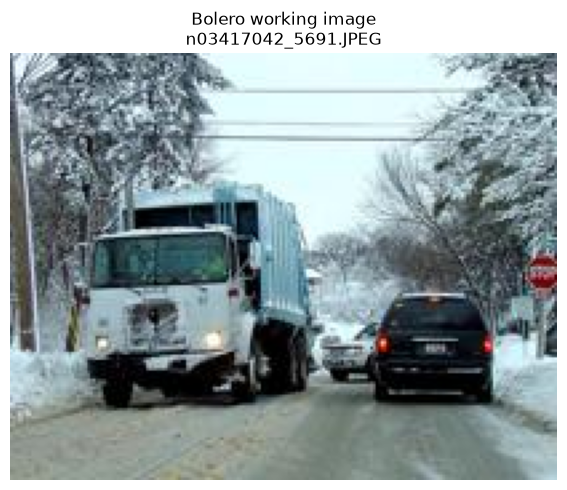

In [78]:
# ============================================================
# BOLERO
# Cell 8: Select and load a working image
# ============================================================

print("=" * 70)
print("BOLERO - IMAGE INITIALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Locate the Imagenette validation images
# ------------------------------------------------------------

SHARED_DATA_ROOT = Path(
    r"F:\DeepLearningTest\clip_corruption_calibration_repo"
) / "clip_corruption_calibration" / "data" / "imagenette2-160"

VAL_DIR = SHARED_DATA_ROOT / "val"

if not VAL_DIR.exists():
    raise FileNotFoundError(
        f"Validation directory not found:\n{VAL_DIR}"
    )

# ------------------------------------------------------------
# Find available images
# ------------------------------------------------------------

image_files = sorted(
    [
        path
        for path in VAL_DIR.rglob("*")
        if path.is_file()
        and path.suffix in IMAGE_EXTENSIONS
    ]
)

if not image_files:
    raise FileNotFoundError(
        f"No images found under:\n{VAL_DIR}"
    )

print("\nImages available:")
print(len(image_files))

# ------------------------------------------------------------
# Select a deterministic working image
#
# We use the same seed throughout Bolero so that the visual
# construction is reproducible.
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

IMAGE_INDEX = int(
    rng.integers(
        0,
        len(image_files),
    )
)

IMAGE_PATH = random.choice(image_files)
# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------

image = Image.open(
    IMAGE_PATH
).convert("RGB")

# ------------------------------------------------------------
# Basic image metadata
# ------------------------------------------------------------

IMAGE_WIDTH, IMAGE_HEIGHT = image.size

image_array = np.asarray(
    image
).astype(np.float32) / 255.0

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nSelected image:")
print(IMAGE_PATH)

print("\nImage index:")
print(IMAGE_INDEX)

print("\nImage size:")
print(
    f"{IMAGE_WIDTH} × {IMAGE_HEIGHT}"
)

print("\nImage mode:")
print(image.mode)

print("\n✓ Image initialized successfully.")

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.imshow(image)

plt.title(
    f"Bolero working image\n{IMAGE_PATH.name}"
)

plt.axis("off")

plt.tight_layout()
plt.show()

Selected image:
F:\DeepLearningTest\clip_corruption_calibration_repo\clip_corruption_calibration\data\imagenette2-160\val\n02102040\n02102040_1781.JPEG

Image size:
(160, 200)

Depth statistics:
Minimum: 0.0000
Maximum: 1.0000
Mean:    0.5022
Median:  0.5179
Std:     0.2835


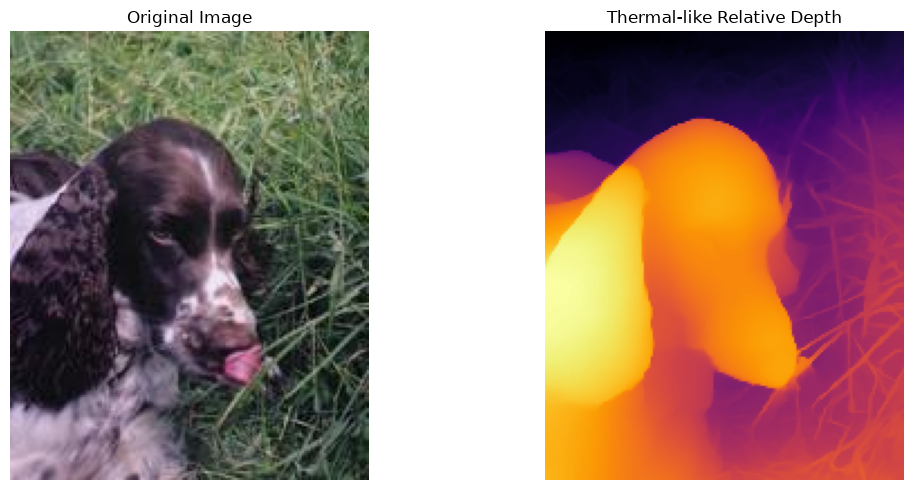

In [79]:
# Cell 9: Thermal-like depth representation

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ------------------------------------------------------------
# Select a fresh random image
# ------------------------------------------------------------

image_files = sorted(
    [
        path
        for path in VAL_DIR.rglob("*")
        if path.is_file()
        and path.suffix in IMAGE_EXTENSIONS
    ]
)

IMAGE_PATH = random.choice(image_files)

image = Image.open(
    IMAGE_PATH
).convert("RGB")

image_array = (
    np.asarray(image)
    .astype(np.float32)
    / 255.0
)

print("Selected image:")
print(IMAGE_PATH)

print("\nImage size:")
print(image.size)

# ------------------------------------------------------------
# Initialize depth model if necessary
# ------------------------------------------------------------

if "depth_processor" not in globals():
    print("\nLoading depth processor...")
    depth_processor = AutoImageProcessor.from_pretrained(
        DEPTH_MODEL_NAME
    )

if "depth_model" not in globals():
    print("Loading depth model...")
    depth_model = AutoModelForDepthEstimation.from_pretrained(
        DEPTH_MODEL_NAME
    )

    depth_model = depth_model.to(DEVICE)
    depth_model.eval()

# ------------------------------------------------------------
# Estimate depth
# ------------------------------------------------------------

depth_inputs = depth_processor(
    images=image,
    return_tensors="pt"
)

depth_inputs = {
    key: value.to(DEVICE)
    for key, value in depth_inputs.items()
}

with torch.no_grad():
    depth_outputs = depth_model(
        **depth_inputs
    )

depth_prediction = (
    depth_outputs.predicted_depth
)

depth_prediction = F.interpolate(
    depth_prediction.unsqueeze(1),
    size=(image.height, image.width),
    mode="bicubic",
    align_corners=False,
).squeeze()

depth_map = (
    depth_prediction
    .cpu()
    .numpy()
)

# ------------------------------------------------------------
# Normalize relative depth
# ------------------------------------------------------------

depth_min = float(depth_map.min())
depth_max = float(depth_map.max())

depth_map = (
    depth_map - depth_min
) / (
    depth_max - depth_min + 1e-8
)

print("\nDepth statistics:")
print(f"Minimum: {depth_map.min():.4f}")
print(f"Maximum: {depth_map.max():.4f}")
print(f"Mean:    {depth_map.mean():.4f}")
print(f"Median:  {np.median(depth_map):.4f}")
print(f"Std:     {depth_map.std():.4f}")

# ------------------------------------------------------------
# Thermal-like visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    depth_map,
    cmap="inferno"
)
plt.title("Thermal-like Relative Depth")
plt.axis("off")

plt.tight_layout()
plt.show()

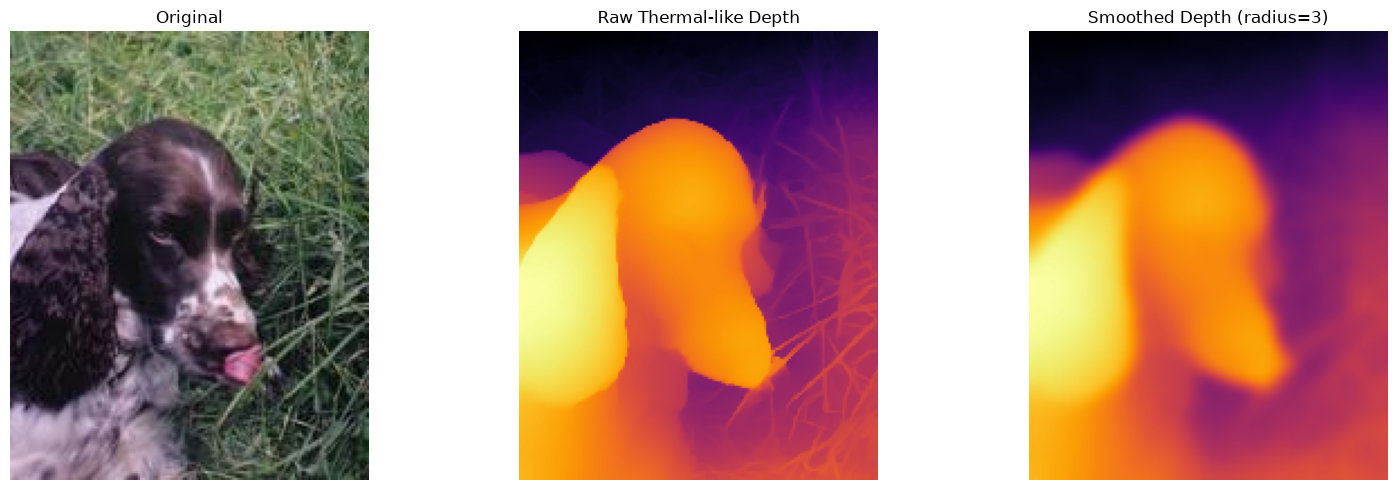

Depth field analysis:
Raw gradient mean:      0.011868
Smoothed gradient mean: 0.008353
Raw gradient std:       0.026226
Smoothed gradient std:  0.010708

✓ Thermal representation established.
✓ Smoothed spatial field established.


In [80]:
# Cell 10: Smoothed thermal depth field

from PIL import ImageFilter

SMOOTH_RADIUS = 3

depth_uint8 = np.uint8(
    depth_map * 255
)

depth_image = Image.fromarray(
    depth_uint8
)

smoothed_depth_image = depth_image.filter(
    ImageFilter.GaussianBlur(
        radius=SMOOTH_RADIUS
    )
)

smoothed_depth = (
    np.asarray(
        smoothed_depth_image
    ).astype(np.float32)
    / 255.0
)

# ------------------------------------------------------------
# Compare raw and smoothed depth
# ------------------------------------------------------------

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    depth_map,
    cmap="inferno"
)
plt.title("Raw Thermal-like Depth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    smoothed_depth,
    cmap="inferno"
)
plt.title(
    f"Smoothed Depth (radius={SMOOTH_RADIUS})"
)
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Quantify the effect of smoothing
# ------------------------------------------------------------

raw_gradient_y, raw_gradient_x = np.gradient(
    depth_map
)

smooth_gradient_y, smooth_gradient_x = np.gradient(
    smoothed_depth
)

raw_gradient = np.sqrt(
    raw_gradient_x ** 2
    + raw_gradient_y ** 2
)

smooth_gradient = np.sqrt(
    smooth_gradient_x ** 2
    + smooth_gradient_y ** 2
)

print("Depth field analysis:")
print(
    f"Raw gradient mean:      "
    f"{raw_gradient.mean():.6f}"
)

print(
    f"Smoothed gradient mean: "
    f"{smooth_gradient.mean():.6f}"
)

print(
    f"Raw gradient std:       "
    f"{raw_gradient.std():.6f}"
)

print(
    f"Smoothed gradient std:  "
    f"{smooth_gradient.std():.6f}"
)

print("\n✓ Thermal representation established.")
print("✓ Smoothed spatial field established.")

Depth boundary analysis:
Boundary threshold: 0.023314
Boundary coverage: 10.00%


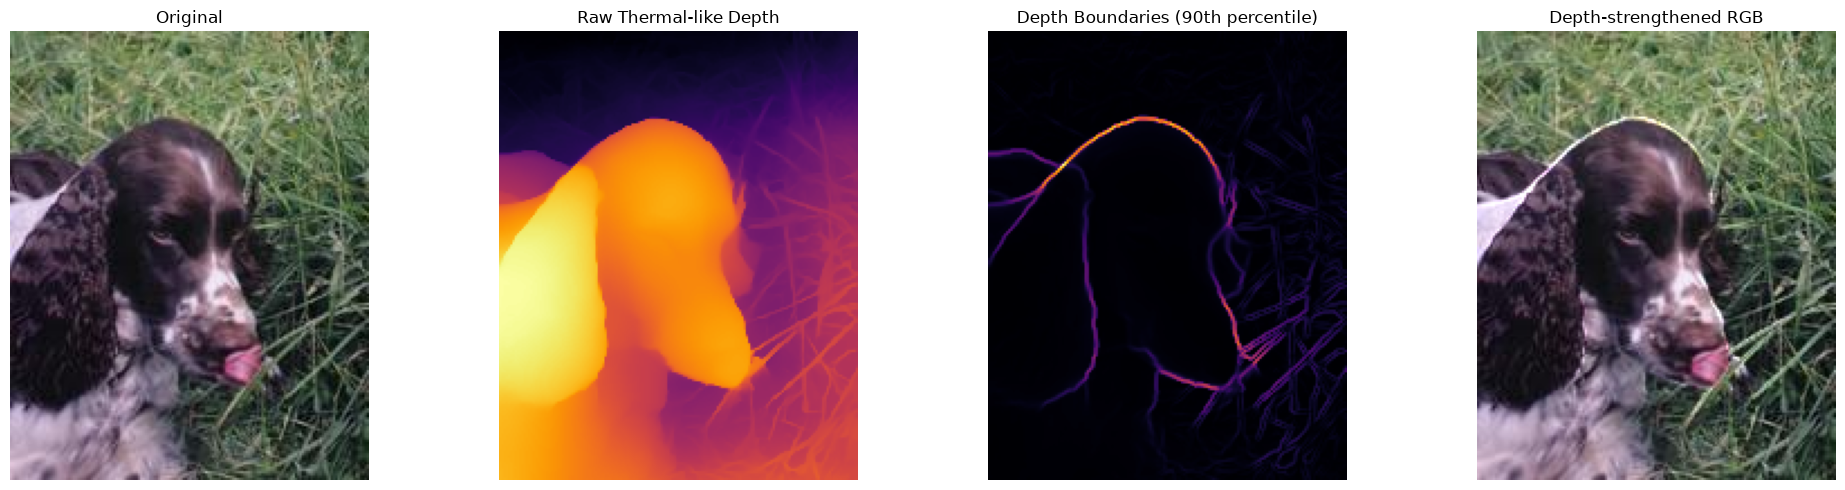


✓ Raw depth boundaries extracted.
✓ Context-preserving border enhancement created.


In [85]:
# Cell 11: Depth boundary and border strengthening

# ------------------------------------------------------------
# Compute depth gradients from RAW depth
# ------------------------------------------------------------

depth_dy, depth_dx = np.gradient(
    depth_map
)

depth_gradient = np.sqrt(
    depth_dx ** 2
    + depth_dy ** 2
)

# ------------------------------------------------------------
# Identify strongest depth boundaries
# ------------------------------------------------------------

BOUNDARY_PERCENTILE = 90

boundary_threshold = np.percentile(
    depth_gradient,
    BOUNDARY_PERCENTILE
)

depth_boundary = (
    depth_gradient >= boundary_threshold
)

boundary_coverage = (
    100.0
    * depth_boundary.mean()
)

print("Depth boundary analysis:")
print(
    f"Boundary threshold: "
    f"{boundary_threshold:.6f}"
)

print(
    f"Boundary coverage: "
    f"{boundary_coverage:.2f}%"
)

# ------------------------------------------------------------
# Normalize boundary strength
# ------------------------------------------------------------

boundary_strength = (
    depth_gradient
    / (
        depth_gradient.max()
        + 1e-8
    )
)

# ------------------------------------------------------------
# Strengthen borders on original RGB
# ------------------------------------------------------------

BORDER_STRENGTH = 1.75

border_enhanced_array = (
    image_array.copy()
)

# Brighten the local structure where
# depth changes are strongest.
border_factor = (
    1.0
    + BORDER_STRENGTH
    * boundary_strength[..., None]
)

border_enhanced_array = np.clip(
    border_enhanced_array
    * border_factor,
    0.0,
    1.0
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(
    depth_map,
    cmap="inferno"
)
plt.title("Raw Thermal-like Depth")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    depth_gradient,
    cmap="inferno"
)
plt.title(
    f"Depth Boundaries ({BOUNDARY_PERCENTILE}th percentile)"
)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(
    border_enhanced_array
)
plt.title("Depth-strengthened RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n✓ Raw depth boundaries extracted.")
print("✓ Context-preserving border enhancement created.")

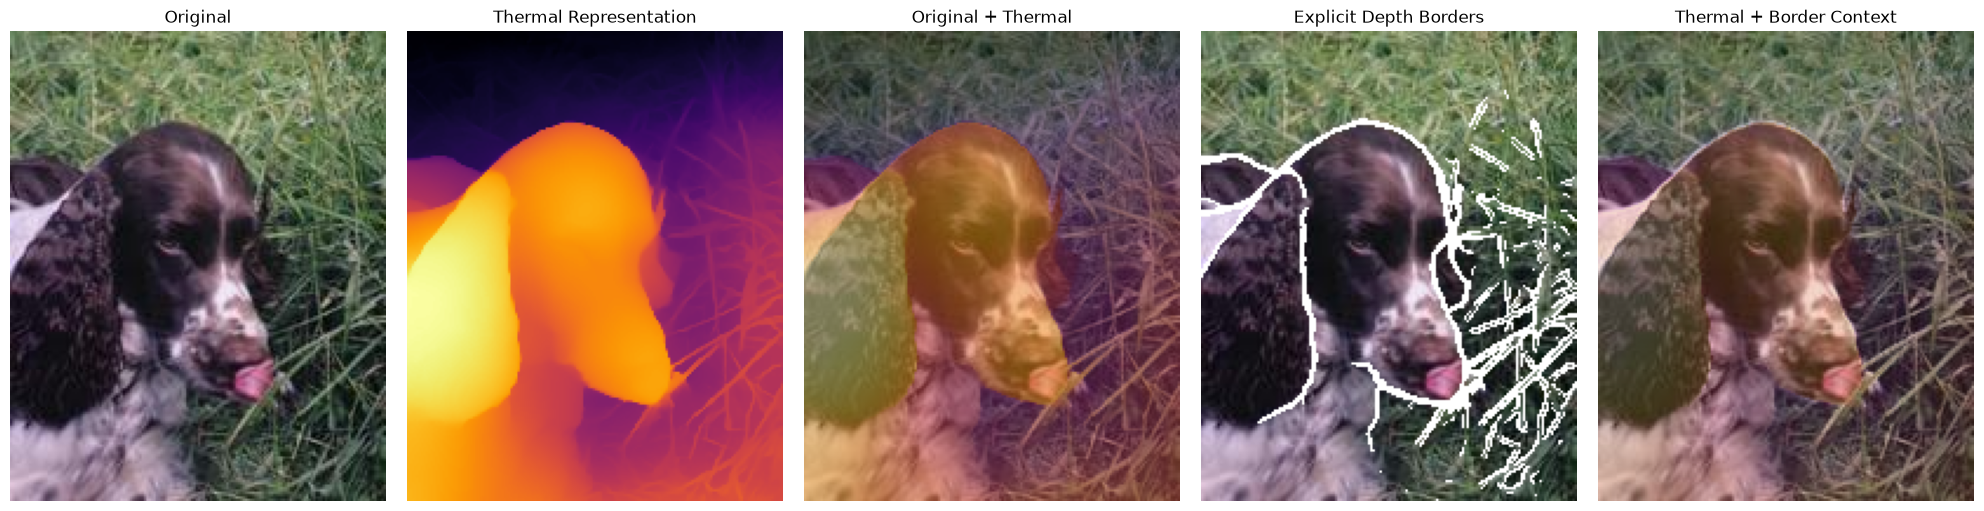

Contextual representations created:
1. Thermal representation
2. Original + thermal
3. Explicit depth borders
4. Thermal + border context

✓ No image regions were removed.
✓ Object context is preserved.


In [86]:
# Cell 12: Thermal and border contextual fusion

# ------------------------------------------------------------
# Create normalized thermal RGB representation
# ------------------------------------------------------------

thermal_rgb = plt.get_cmap("inferno")(
    depth_map
)[..., :3]

# ------------------------------------------------------------
# Blend original image with thermal representation
# ------------------------------------------------------------

THERMAL_BLEND = 0.45

thermal_context = (
    (1.0 - THERMAL_BLEND)
    * image_array
    +
    THERMAL_BLEND
    * thermal_rgb
)

thermal_context = np.clip(
    thermal_context,
    0.0,
    1.0
)

# ------------------------------------------------------------
# Combine thermal context with border enhancement
# ------------------------------------------------------------

BORDER_BLEND = 0.55

thermal_border_context = (
    (1.0 - BORDER_BLEND)
    * thermal_context
    +
    BORDER_BLEND
    * border_enhanced_array
)

thermal_border_context = np.clip(
    thermal_border_context,
    0.0,
    1.0
)

# ------------------------------------------------------------
# Explicit boundary overlay
# ------------------------------------------------------------

boundary_overlay = (
    image_array.copy()
)

boundary_overlay[
    depth_boundary
] = 1.0

# ------------------------------------------------------------
# Display all contextual representations
# ------------------------------------------------------------

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(thermal_rgb)
plt.title("Thermal Representation")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(thermal_context)
plt.title("Original + Thermal")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(boundary_overlay)
plt.title("Explicit Depth Borders")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(thermal_border_context)
plt.title("Thermal + Border Context")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Contextual representations created:")
print(
    "1. Thermal representation"
)

print(
    "2. Original + thermal"
)

print(
    "3. Explicit depth borders"
)

print(
    "4. Thermal + border context"
)

print("\n✓ No image regions were removed.")
print("✓ Object context is preserved.")

In [87]:
# Cell 13: Recognition model

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
)

RECOGNITION_MODEL_NAME = (
    "microsoft/resnet-50"
)

if "recognition_processor" not in globals():
    recognition_processor = (
        AutoImageProcessor.from_pretrained(
            RECOGNITION_MODEL_NAME
        )
    )

if "recognition_model" not in globals():
    print("Loading recognition model...")

    recognition_model = (
        AutoModelForImageClassification
        .from_pretrained(
            RECOGNITION_MODEL_NAME
        )
    )

    recognition_model = (
        recognition_model.to(DEVICE)
    )

    recognition_model.eval()

print("Recognition model:")
print(
    type(recognition_model).__name__
)

print("\nDevice:")
print(DEVICE)

print("\nNumber of classes:")
print(
    recognition_model.config.num_labels
)

print("\n✓ Recognition model ready.")

Loading recognition model...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Recognition model:
ResNetForImageClassification

Device:
cpu

Number of classes:
1000

✓ Recognition model ready.


In [88]:
# Cell 14: Recognition predictions across Bolero representations

def predict_image(
    image_input,
    model=recognition_model,
    processor=recognition_processor,
):
    """
    Run ImageNet classification and return
    predicted label and confidence.
    """

    if isinstance(
        image_input,
        np.ndarray
    ):
        image_input = Image.fromarray(
            np.uint8(
                np.clip(
                    image_input,
                    0.0,
                    1.0
                ) * 255
            )
        ).convert("RGB")

    inputs = processor(
        images=image_input,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    confidence, prediction = (
        probabilities.max(dim=-1)
    )

    prediction_id = int(
        prediction.item()
    )

    confidence_value = float(
        confidence.item()
    )

    label = (
        model.config.id2label[
            prediction_id
        ]
    )

    return (
        label,
        confidence_value,
        prediction_id
    )


# ------------------------------------------------------------
# Prepare representations
# ------------------------------------------------------------

representations = {
    "Original": image,
    "Raw Thermal": Image.fromarray(
        np.uint8(
            thermal_rgb * 255
        )
    ),
    "Smoothed Thermal": Image.fromarray(
        np.uint8(
            plt.get_cmap("inferno")(
                smoothed_depth
            )[..., :3] * 255
        )
    ),
    "Border Enhanced": Image.fromarray(
        np.uint8(
            border_enhanced_array * 255
        )
    ),
    "Original + Thermal": Image.fromarray(
        np.uint8(
            thermal_context * 255
        )
    ),
    "Thermal + Border": Image.fromarray(
        np.uint8(
            thermal_border_context * 255
        )
    ),
}

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

prediction_results = []

for representation_name, representation_image in (
    representations.items()
):

    label, confidence, prediction_id = (
        predict_image(
            representation_image
        )
    )

    prediction_results.append(
        {
            "representation": representation_name,
            "prediction": label,
            "prediction_id": prediction_id,
            "confidence": confidence,
        }
    )

prediction_results = pd.DataFrame(
    prediction_results
)

print(
    prediction_results[
        [
            "representation",
            "prediction",
            "confidence"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Prediction agreement with original
# ------------------------------------------------------------

original_prediction_id = int(
    prediction_results.loc[
        prediction_results["representation"]
        == "Original",
        "prediction_id"
    ].iloc[0]
)

prediction_results[
    "changed_from_original"
] = (
    prediction_results["prediction_id"]
    != original_prediction_id
)

print("\nPrediction changes relative to Original:")

print(
    prediction_results[
        [
            "representation",
            "changed_from_original"
        ]
    ].to_string(index=False)
)

print("\n✓ Recognition comparison complete.")

    representation                                 prediction  confidence
          Original English springer, English springer spaniel    0.591865
       Raw Thermal                                  jellyfish    0.259129
  Smoothed Thermal                                 matchstick    0.743303
   Border Enhanced English springer, English springer spaniel    0.502099
Original + Thermal                   Irish setter, red setter    0.565317
  Thermal + Border                             Sussex spaniel    0.465298

Prediction changes relative to Original:
    representation  changed_from_original
          Original                  False
       Raw Thermal                   True
  Smoothed Thermal                   True
   Border Enhanced                  False
Original + Thermal                   True
  Thermal + Border                   True

✓ Recognition comparison complete.


Baseline:
English springer, English springer spaniel (0.592)

Thermal strength sweep:
 strength                                 prediction  confidence  changed
      0.0 English springer, English springer spaniel    0.591865    False
      0.1 English springer, English springer spaniel    0.410985    False
      0.2                             Sussex spaniel    0.489585     True
      0.3                             Sussex spaniel    0.746052     True
      0.4                             Sussex spaniel    0.432442     True
      0.5                   Irish setter, red setter    0.577368     True
      0.6                   Irish setter, red setter    0.293631     True
      0.7                                bell pepper    0.539476     True
      0.8                                bell pepper    0.659771     True
      0.9                                bell pepper    0.638702     True
      1.0                                  jellyfish    0.259129     True

Border strength sweep:
 s

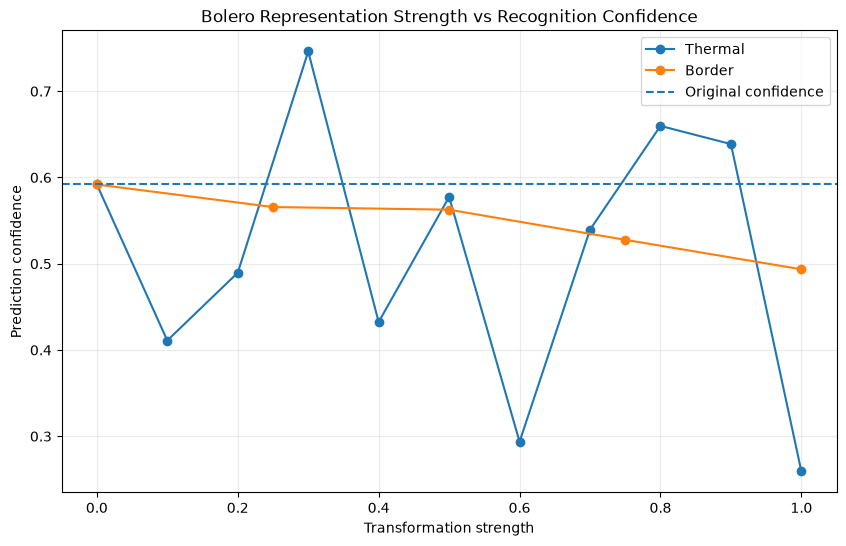

In [89]:
# Cell 15: Controlled Bolero strength sweep

# ------------------------------------------------------------
# Strength ranges
# ------------------------------------------------------------

THERMAL_STRENGTHS = [
    0.00,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00,
]

BORDER_STRENGTHS = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
]

strength_results = []

# ------------------------------------------------------------
# Baseline prediction
# ------------------------------------------------------------

baseline_label, baseline_confidence, baseline_id = (
    predict_image(image)
)

print("Baseline:")
print(
    f"{baseline_label} "
    f"({baseline_confidence:.3f})"
)

# ------------------------------------------------------------
# Thermal strength sweep
# ------------------------------------------------------------

for strength in THERMAL_STRENGTHS:

    blended = (
        (1.0 - strength)
        * image_array
        +
        strength
        * thermal_rgb
    )

    label, confidence, prediction_id = (
        predict_image(blended)
    )

    strength_results.append(
        {
            "type": "thermal",
            "strength": strength,
            "prediction": label,
            "prediction_id": prediction_id,
            "confidence": confidence,
            "changed": (
                prediction_id != baseline_id
            ),
        }
    )

# ------------------------------------------------------------
# Border strength sweep
# ------------------------------------------------------------

for strength in BORDER_STRENGTHS:

    # Recreate border enhancement at
    # the requested strength.
    factor = (
        1.0
        + strength
        * boundary_strength[..., None]
    )

    bordered = np.clip(
        image_array * factor,
        0.0,
        1.0
    )

    label, confidence, prediction_id = (
        predict_image(bordered)
    )

    strength_results.append(
        {
            "type": "border",
            "strength": strength,
            "prediction": label,
            "prediction_id": prediction_id,
            "confidence": confidence,
            "changed": (
                prediction_id != baseline_id
            ),
        }
    )

strength_results = pd.DataFrame(
    strength_results
)

print("\nThermal strength sweep:")
print(
    strength_results[
        strength_results["type"] == "thermal"
    ][
        [
            "strength",
            "prediction",
            "confidence",
            "changed",
        ]
    ].to_string(index=False)
)

print("\nBorder strength sweep:")
print(
    strength_results[
        strength_results["type"] == "border"
    ][
        [
            "strength",
            "prediction",
            "confidence",
            "changed",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Plot confidence against strength
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for method_type in ["thermal", "border"]:

    subset = strength_results[
        strength_results["type"]
        == method_type
    ]

    plt.plot(
        subset["strength"],
        subset["confidence"],
        marker="o",
        label=method_type.title()
    )

plt.axhline(
    baseline_confidence,
    linestyle="--",
    label="Original confidence"
)

plt.xlabel("Transformation strength")
plt.ylabel("Prediction confidence")
plt.title(
    "Bolero Representation Strength vs Recognition Confidence"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

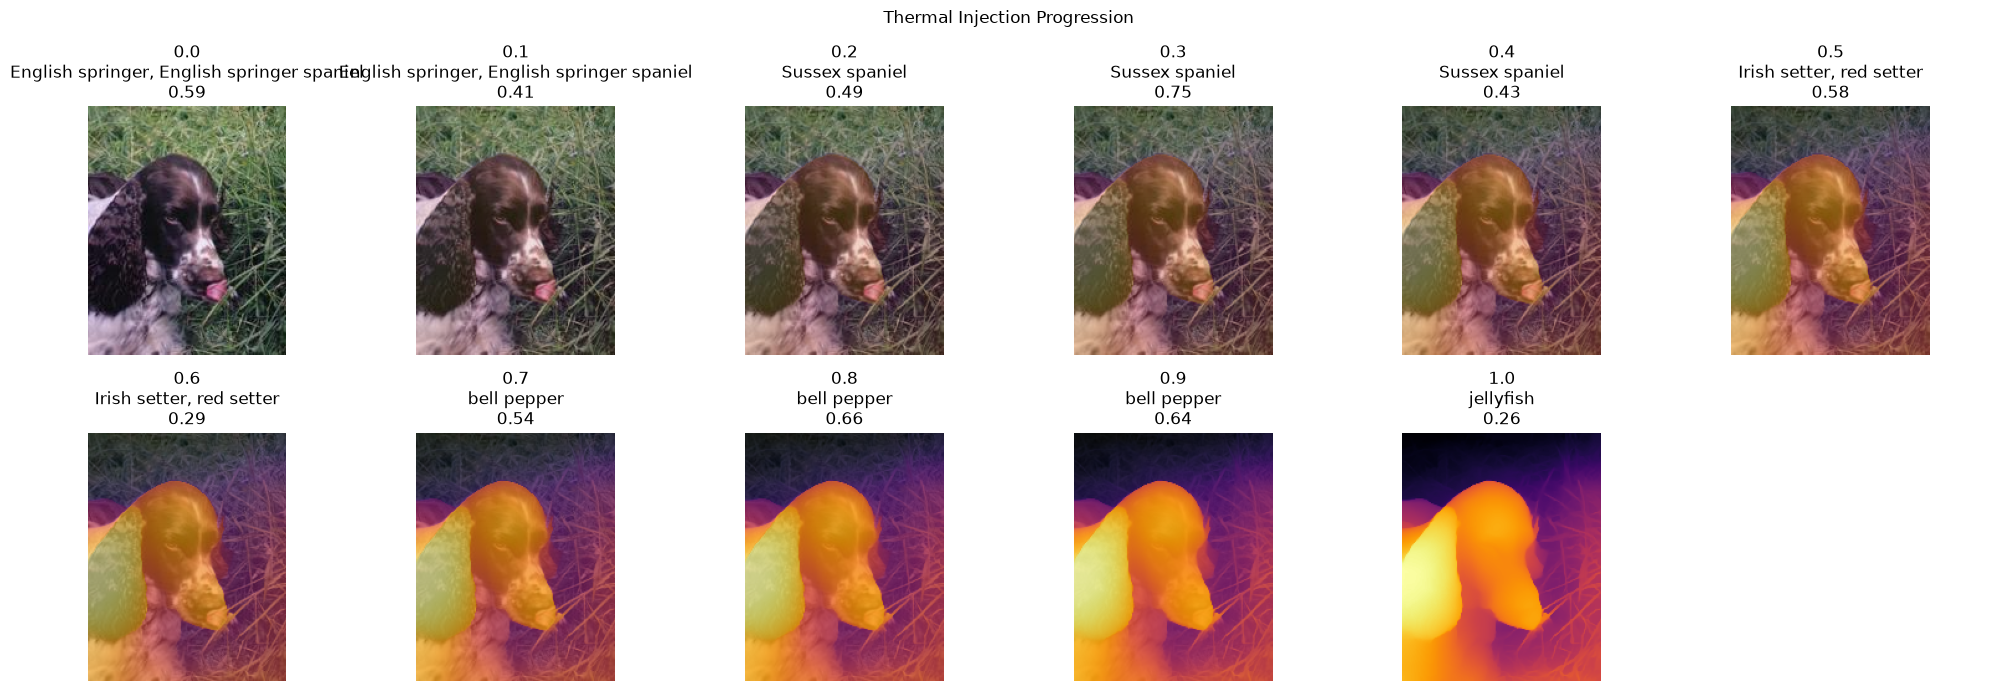

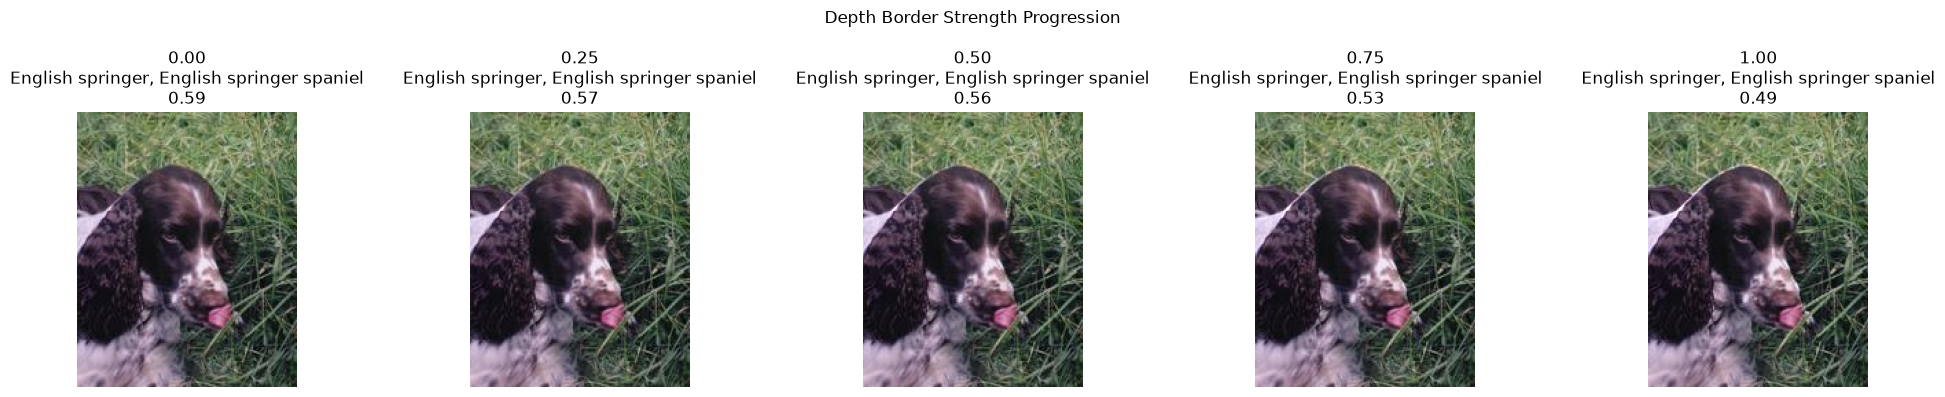

In [90]:
# Cell 16: Visual progression of Bolero transformations

thermal_subset = strength_results[
    strength_results["type"] == "thermal"
]

border_subset = strength_results[
    strength_results["type"] == "border"
]

# ------------------------------------------------------------
# Thermal progression
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    6,
    figsize=(20, 7)
)

axes = axes.ravel()

for ax in axes:
    ax.axis("off")

for index, row in thermal_subset.iterrows():

    strength = row["strength"]

    blended = (
        (1.0 - strength)
        * image_array
        +
        strength
        * thermal_rgb
    )

    axes[index].imshow(
        np.clip(blended, 0.0, 1.0)
    )

    axes[index].set_title(
        f"{strength:.1f}\n"
        f"{row['prediction']}\n"
        f"{row['confidence']:.2f}"
    )

plt.suptitle(
    "Thermal Injection Progression"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Border progression
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(BORDER_STRENGTHS),
    figsize=(20, 4)
)

for ax, (_, row) in zip(
    axes,
    border_subset.iterrows()
):

    strength = row["strength"]

    factor = (
        1.0
        + strength
        * boundary_strength[..., None]
    )

    bordered = np.clip(
        image_array * factor,
        0.0,
        1.0
    )

    ax.imshow(bordered)

    ax.set_title(
        f"{strength:.2f}\n"
        f"{row['prediction']}\n"
        f"{row['confidence']:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Depth Border Strength Progression"
)

plt.tight_layout()
plt.show()

Thermal / boundary correspondence
----------------------------------
Strong thermal pixels:   8,000 (25.00%)
Strong boundary pixels:  8,000 (25.00%)
Overlap:                 777
Intersection / Union:    0.0510
Thermal covered by border: 0.0971
Border covered by thermal: 0.0971

Spatial relationship:
Thermal + Boundary: 2.43%
Thermal only:       22.57%
Boundary only:      22.57%
Neither:            52.43%


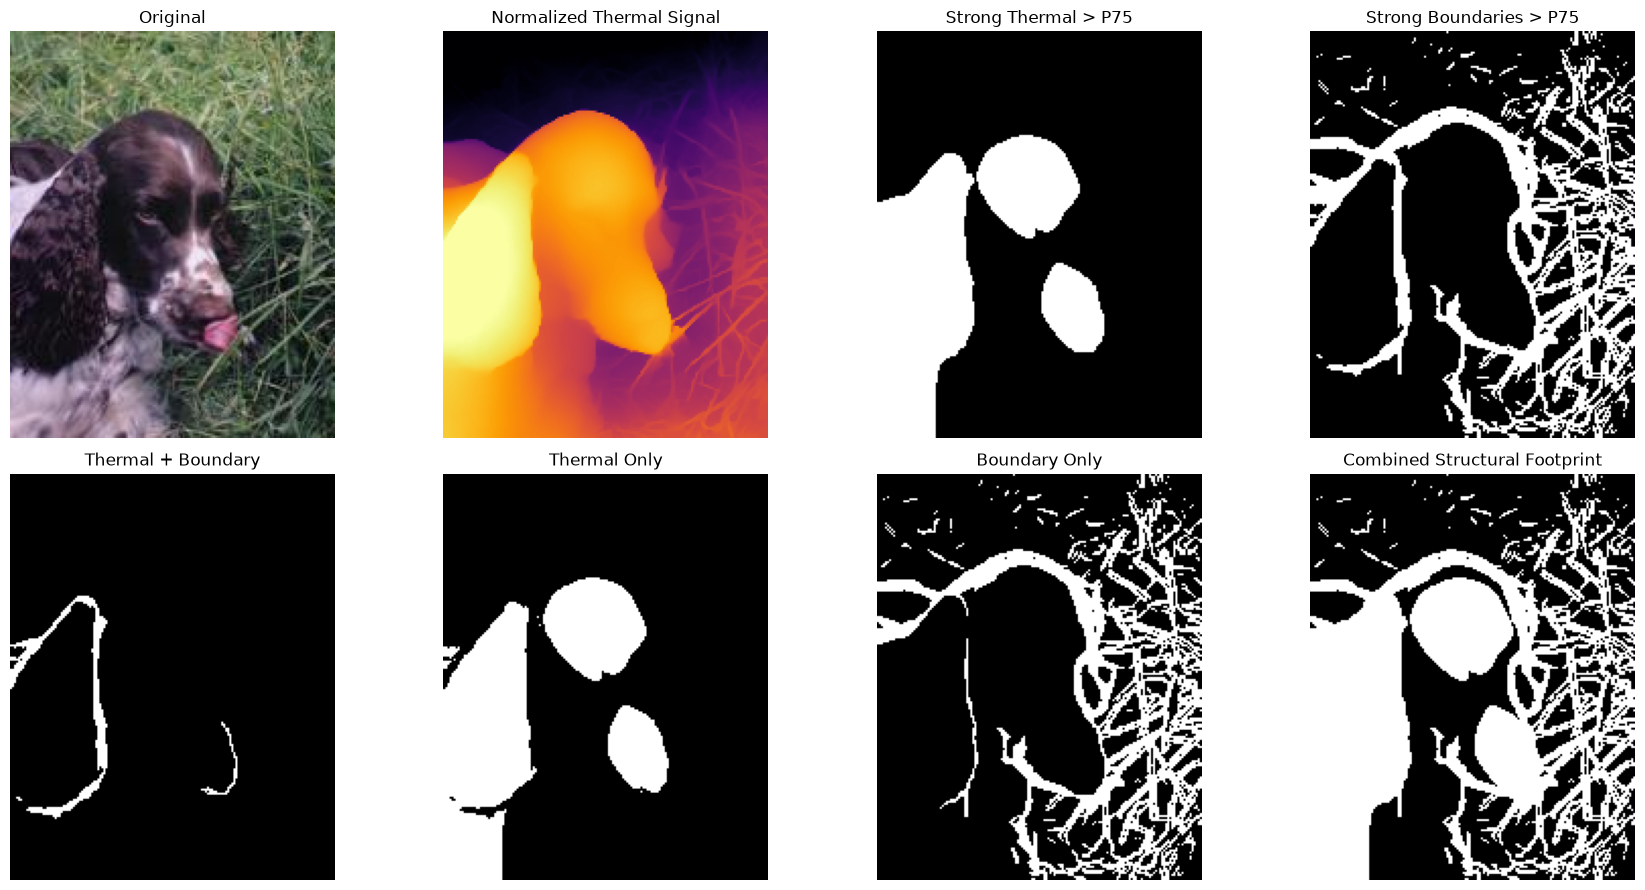


✓ Thermal structure and boundary correspondence analyzed.


In [91]:
# Cell 17: Thermal structure and boundary correspondence

# ------------------------------------------------------------
# 1. Normalize the raw depth field
# ------------------------------------------------------------

thermal_signal = depth_map.copy()

thermal_low = np.percentile(
    thermal_signal,
    5
)

thermal_high = np.percentile(
    thermal_signal,
    95
)

thermal_normalized = np.clip(
    (
        thermal_signal - thermal_low
    )
    / (
        thermal_high - thermal_low
        + 1e-8
    ),
    0.0,
    1.0
)

# ------------------------------------------------------------
# 2. Define strong thermal regions
# ------------------------------------------------------------

THERMAL_PERCENTILE = 75

thermal_threshold = np.percentile(
    thermal_normalized,
    THERMAL_PERCENTILE
)

thermal_strong = (
    thermal_normalized
    >= thermal_threshold
)

# ------------------------------------------------------------
# 3. Define strong boundary regions
# ------------------------------------------------------------

boundary_strength_normalized = (
    depth_gradient
    / (
        depth_gradient.max()
        + 1e-8
    )
)

BOUNDARY_ANALYSIS_PERCENTILE = 75

boundary_analysis_threshold = np.percentile(
    boundary_strength_normalized,
    BOUNDARY_ANALYSIS_PERCENTILE
)

boundary_strong = (
    boundary_strength_normalized
    >= boundary_analysis_threshold
)

# ------------------------------------------------------------
# 4. Compare spatial correspondence
# ------------------------------------------------------------

thermal_pixels = int(
    thermal_strong.sum()
)

boundary_pixels = int(
    boundary_strong.sum()
)

overlap = (
    thermal_strong
    & boundary_strong
)

union = (
    thermal_strong
    | boundary_strong
)

overlap_pixels = int(
    overlap.sum()
)

union_pixels = int(
    union.sum()
)

intersection_over_union = (
    overlap_pixels
    / (union_pixels + 1e-8)
)

thermal_to_boundary = (
    overlap_pixels
    / (thermal_pixels + 1e-8)
)

boundary_to_thermal = (
    overlap_pixels
    / (boundary_pixels + 1e-8)
)

print("Thermal / boundary correspondence")
print("----------------------------------")

print(
    f"Strong thermal pixels:   "
    f"{thermal_pixels:,} "
    f"({100 * thermal_strong.mean():.2f}%)"
)

print(
    f"Strong boundary pixels:  "
    f"{boundary_pixels:,} "
    f"({100 * boundary_strong.mean():.2f}%)"
)

print(
    f"Overlap:                 "
    f"{overlap_pixels:,}"
)

print(
    f"Intersection / Union:    "
    f"{intersection_over_union:.4f}"
)

print(
    f"Thermal covered by border:"
    f" {thermal_to_boundary:.4f}"
)

print(
    f"Border covered by thermal:"
    f" {boundary_to_thermal:.4f}"
)

# ------------------------------------------------------------
# 5. Four-way structural relationship
# ------------------------------------------------------------

thermal_only = (
    thermal_strong
    & ~boundary_strong
)

boundary_only = (
    boundary_strong
    & ~thermal_strong
)

neither = (
    ~thermal_strong
    & ~boundary_strong
)

print("\nSpatial relationship:")
print(
    f"Thermal + Boundary: "
    f"{100 * overlap.mean():.2f}%"
)

print(
    f"Thermal only:       "
    f"{100 * thermal_only.mean():.2f}%"
)

print(
    f"Boundary only:      "
    f"{100 * boundary_only.mean():.2f}%"
)

print(
    f"Neither:            "
    f"{100 * neither.mean():.2f}%"
)

# ------------------------------------------------------------
# 6. Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes[0, 0].imshow(
    image
)
axes[0, 0].set_title("Original")

axes[0, 1].imshow(
    thermal_normalized,
    cmap="inferno"
)
axes[0, 1].set_title(
    "Normalized Thermal Signal"
)

axes[0, 2].imshow(
    thermal_strong,
    cmap="gray"
)
axes[0, 2].set_title(
    f"Strong Thermal > P{THERMAL_PERCENTILE}"
)

axes[0, 3].imshow(
    boundary_strong,
    cmap="gray"
)
axes[0, 3].set_title(
    f"Strong Boundaries > P{BOUNDARY_ANALYSIS_PERCENTILE}"
)

axes[1, 0].imshow(
    overlap,
    cmap="gray"
)
axes[1, 0].set_title(
    "Thermal + Boundary"
)

axes[1, 1].imshow(
    thermal_only,
    cmap="gray"
)
axes[1, 1].set_title(
    "Thermal Only"
)

axes[1, 2].imshow(
    boundary_only,
    cmap="gray"
)
axes[1, 2].set_title(
    "Boundary Only"
)

axes[1, 3].imshow(
    union,
    cmap="gray"
)
axes[1, 3].set_title(
    "Combined Structural Footprint"
)

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

print(
    "\n✓ Thermal structure and boundary "
    "correspondence analyzed."
)

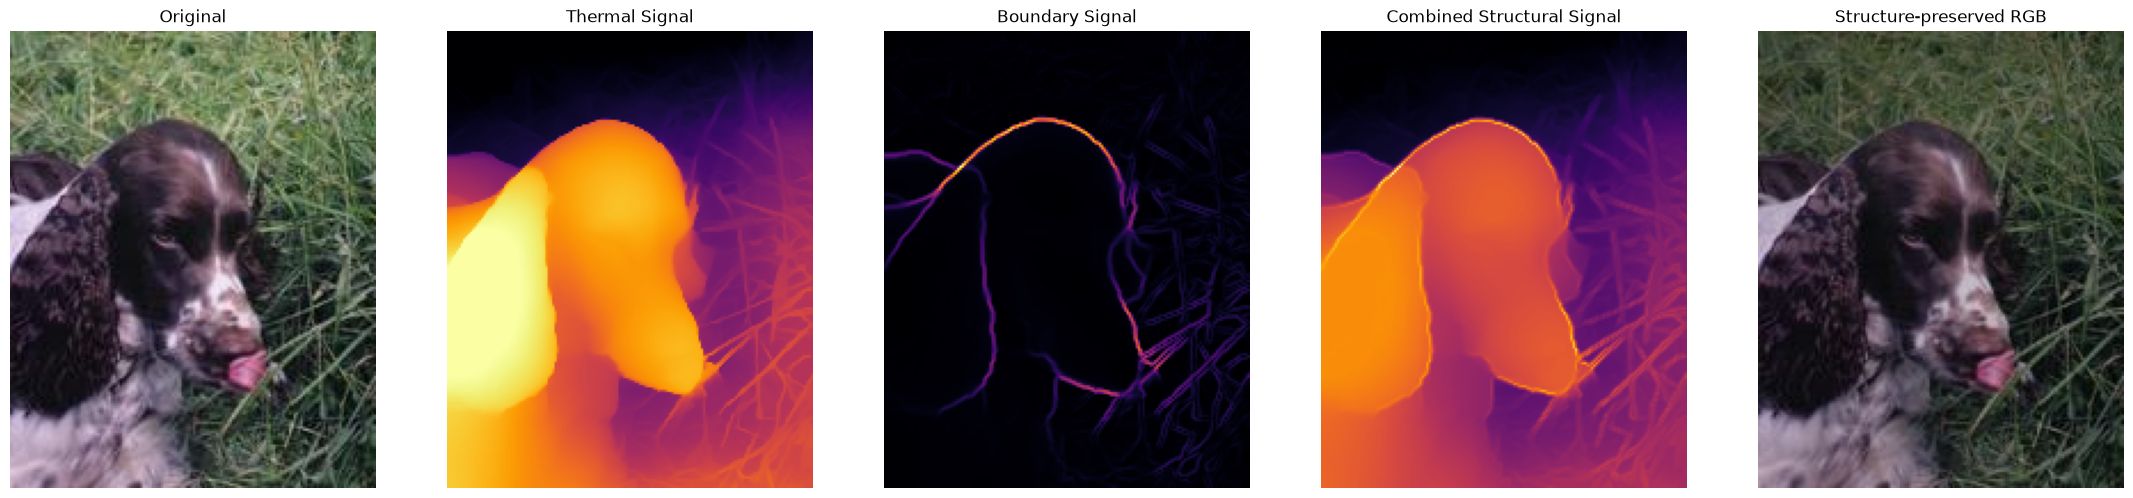

Structural signal:
Mean:   0.3934
Median: 0.4168
Std:    0.2356
Strong structural coverage (P80): 20.00%

✓ Continuous structural correspondence map created.
✓ Original RGB context preserved.


In [92]:
# Cell 18: Structural correspondence heatmap

# ------------------------------------------------------------
# Build continuous structural signal
# ------------------------------------------------------------

thermal_component = (
    thermal_normalized
)

boundary_component = (
    boundary_strength_normalized
)

# Normalize both components independently
thermal_component = (
    thermal_component
    / (
        thermal_component.max()
        + 1e-8
    )
)

boundary_component = (
    boundary_component
    / (
        boundary_component.max()
        + 1e-8
    )
)

# Combined structural signal
THERMAL_WEIGHT = 0.60
BOUNDARY_WEIGHT = 0.40

structural_signal = (
    THERMAL_WEIGHT
    * thermal_component
    +
    BOUNDARY_WEIGHT
    * boundary_component
)

structural_signal = (
    structural_signal
    / (
        structural_signal.max()
        + 1e-8
    )
)

# ------------------------------------------------------------
# Highlight only the strongest structural areas
# ------------------------------------------------------------

STRUCTURAL_PERCENTILE = 80

structural_threshold = np.percentile(
    structural_signal,
    STRUCTURAL_PERCENTILE
)

structural_strong = (
    structural_signal
    >= structural_threshold
)

# ------------------------------------------------------------
# Context-preserving structural image
# ------------------------------------------------------------

structure_overlay = (
    image_array.copy()
)

# Darken weak structural areas slightly
# while preserving the complete image.
attenuation = (
    0.55
    +
    0.45
    * structural_signal[..., None]
)

structure_overlay = np.clip(
    image_array
    * attenuation,
    0.0,
    1.0
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

axes[0].imshow(
    image
)
axes[0].set_title("Original")

axes[1].imshow(
    thermal_component,
    cmap="inferno"
)
axes[1].set_title(
    "Thermal Signal"
)

axes[2].imshow(
    boundary_component,
    cmap="inferno"
)
axes[2].set_title(
    "Boundary Signal"
)

axes[3].imshow(
    structural_signal,
    cmap="inferno"
)
axes[3].set_title(
    "Combined Structural Signal"
)

axes[4].imshow(
    structure_overlay
)
axes[4].set_title(
    "Structure-preserved RGB"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Quantitative summary
# ------------------------------------------------------------

print("Structural signal:")
print(
    f"Mean:   {structural_signal.mean():.4f}"
)

print(
    f"Median: {np.median(structural_signal):.4f}"
)

print(
    f"Std:    {structural_signal.std():.4f}"
)

print(
    f"Strong structural coverage "
    f"(P{STRUCTURAL_PERCENTILE}): "
    f"{100 * structural_strong.mean():.2f}%"
)

print(
    "\n✓ Continuous structural correspondence map created."
)

print(
    "✓ Original RGB context preserved."
)

## Next construction direction

This first implementation is intentionally crude.

The important thing is that we now have an actual executable chain:

**depth → layers → transparency → displacement → shadows → reconstruction**

The next iterations can replace the crude quantile layers with the more useful spatially coherent region representation we discovered during the study, then make displacement depend continuously on depth rather than simply on layer index.

The final cell below is intentionally the opposite of a clean paper figure. It combines the study's major evidence streams with the first constructed Bolero representation into one large visual information dump.


NameError: name 'original_rgb' is not defined

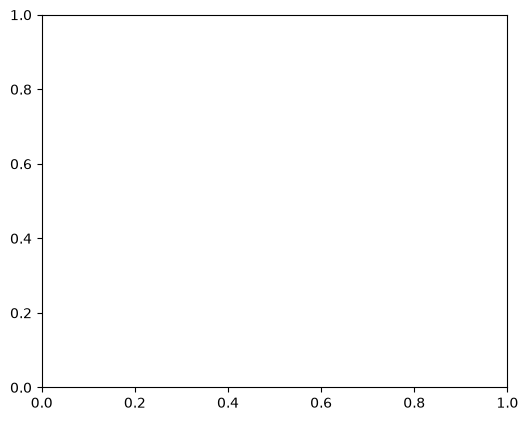

In [84]:
# ============================================================
# BOLERO
# FINAL CELL: VISUALIZATION MESS
# ============================================================

# This cell intentionally produces a dense visual dashboard.
# It is for exploration and "infodump" purposes, not publication.

fig = plt.figure(
    figsize=(28, 24)
)

grid = fig.add_gridspec(
    4,
    4,
    hspace=0.32,
    wspace=0.22,
)

# ------------------------------------------------------------
# 1. Original image
# ------------------------------------------------------------

ax = fig.add_subplot(grid[0, 0])
ax.imshow(original_rgb)
ax.set_title("ORIGINAL")
ax.axis("off")

# ------------------------------------------------------------
# 2. Depth
# ------------------------------------------------------------

ax = fig.add_subplot(grid[0, 1])
ax.imshow(depth_map, cmap="magma")
ax.set_title("RELATIVE DEPTH FIELD")
ax.axis("off")

# ------------------------------------------------------------
# 3. Layer identity
# ------------------------------------------------------------

layer_identity = np.argmax(
    np.stack(layer_masks),
    axis=0,
)

ax = fig.add_subplot(grid[0, 2])
ax.imshow(layer_identity)
ax.set_title("DEPTH LAYER INDEX")
ax.axis("off")

# ------------------------------------------------------------
# 4. Reconstruction
# ------------------------------------------------------------

ax = fig.add_subplot(grid[0, 3])
ax.imshow(final_rgb)
ax.set_title("BOLERO RECONSTRUCTION")
ax.axis("off")

# ------------------------------------------------------------
# 5. Confusion matrix
# ------------------------------------------------------------

ax = fig.add_subplot(grid[1, :2])

conf_values = confusion_matrix.values

ax.imshow(conf_values)

ax.set_xticks(
    range(len(CLASS_NAMES))
)

ax.set_yticks(
    range(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=70,
    ha="right",
    fontsize=7,
)

ax.set_yticklabels(
    CLASS_NAMES,
    fontsize=7,
)

for i in range(
    len(CLASS_NAMES)
):
    for j in range(
        len(CLASS_NAMES)
    ):
        value = conf_values[i, j]

        if value > 0:
            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=7,
            )

ax.set_title(
    "ORIGINAL CONFUSION MATRIX"
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# ------------------------------------------------------------
# 6. TP / FP / FN / TN infodump
# ------------------------------------------------------------

ax = fig.add_subplot(grid[1, 2:])

metric_values = (
    positive_negative_matrix[
        ["TP", "FP", "FN", "TN"]
    ]
    .values
)

x = np.arange(
    len(CLASS_NAMES)
)

width = 0.18

for offset, metric_index in enumerate(
    range(4)
):

    ax.bar(
        x
        + (
            offset
            - 1.5
        )
        * width,
        metric_values[:, metric_index],
        width,
        label=[
            "TP",
            "FP",
            "FN",
            "TN",
        ][metric_index],
    )

ax.set_xticks(x)
ax.set_xticklabels(
    CLASS_NAMES,
    rotation=70,
    ha="right",
    fontsize=7,
)

ax.set_title(
    "POSITIVE / NEGATIVE CLASS RELATIONS"
)

ax.legend(
    fontsize=7
)

# ------------------------------------------------------------
# 7. Growth / loss heatmap
# ------------------------------------------------------------

ax = fig.add_subplot(grid[2, :2])

growth_table = growth_loss.pivot_table(
    index="method",
    columns="class",
    values="correct_gain_loss",
    aggfunc="mean",
    fill_value=0,
)

growth_table = growth_table.reindex(
    columns=[
        class_name
        for class_name in CLASS_NAMES
        if class_name in growth_table.columns
    ]
)

ax.imshow(
    growth_table.values,
)

ax.set_xticks(
    range(
        len(growth_table.columns)
    )
)

ax.set_xticklabels(
    growth_table.columns,
    rotation=70,
    ha="right",
    fontsize=7,
)

ax.set_yticks(
    range(
        len(growth_table.index)
    )
)

ax.set_yticklabels(
    growth_table.index,
    fontsize=7,
)

for i in range(
    len(growth_table.index)
):
    for j in range(
        len(growth_table.columns)
    ):
        value = growth_table.iloc[i, j]

        if abs(value) > 0:
            ax.text(
                j,
                i,
                f"{value:+.0f}",
                ha="center",
                va="center",
                fontsize=6,
            )

ax.set_title(
    "CLASS GROWTH / LOSS RELATIONS"
)

# ------------------------------------------------------------
# 8. Accuracy by method
# ------------------------------------------------------------

ax = fig.add_subplot(grid[2, 2])

method_accuracy = (
    analysis_records
    .groupby(METHOD_COL)["correct"]
    .mean()
    .sort_values()
)

ax.barh(
    method_accuracy.index.astype(str),
    method_accuracy.values * 100,
)

ax.set_xlabel(
    "Accuracy (%)"
)

ax.set_title(
    "METHOD RESPONSE"
)

ax.tick_params(
    axis="y",
    labelsize=7,
)

# ------------------------------------------------------------
# 9. Confidence distribution
# ------------------------------------------------------------

ax = fig.add_subplot(grid[2, 3])

if CONF_COL is not None:

    confidence_values = pd.to_numeric(
        analysis_records[CONF_COL],
        errors="coerce",
    ).dropna()

    ax.hist(
        confidence_values,
        bins=20,
    )

    ax.set_title(
        "CONFIDENCE DISTRIBUTION"
    )

    ax.set_xlabel(
        "Confidence"
    )

else:

    ax.text(
        0.5,
        0.5,
        "No confidence column",
        ha="center",
        va="center",
    )

    ax.set_title(
        "CONFIDENCE DISTRIBUTION"
    )

# ------------------------------------------------------------
# 10. Region / layer coverage
# ------------------------------------------------------------

ax = fig.add_subplot(grid[3, 0])

coverages = [
    mask.mean() * 100
    for mask in layer_masks
]

ax.bar(
    range(
        1,
        len(coverages) + 1,
    ),
    coverages,
)

ax.set_xticks(
    range(
        1,
        len(coverages) + 1,
    )
)

ax.set_xlabel(
    "Depth layer"
)

ax.set_ylabel(
    "Coverage (%)"
)

ax.set_title(
    "LAYER COVERAGE"
)

# ------------------------------------------------------------
# 11. Depth histogram
# ------------------------------------------------------------

ax = fig.add_subplot(grid[3, 1])

ax.hist(
    depth_map.ravel(),
    bins=30,
)

ax.set_title(
    "DEPTH FIELD DISTRIBUTION"
)

ax.set_xlabel(
    "Relative depth"
)

# ------------------------------------------------------------
# 12. Displacement field
# ------------------------------------------------------------

ax = fig.add_subplot(grid[3, 2])

displacement_x = np.linspace(
    -MAX_SHIFT,
    MAX_SHIFT,
    len(displaced_layers),
)

displacement_y = (
    -0.35
    * displacement_x
)

ax.plot(
    displacement_x,
    displacement_y,
    marker="o",
)

for i, (dx, dy) in enumerate(
    zip(
        displacement_x,
        displacement_y,
    ),
    start=1,
):

    ax.annotate(
        f"L{i}",
        (dx, dy),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(
    0,
    linewidth=0.8,
)

ax.axvline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "ARTIFICIAL PARALLAX DISPLACEMENT"
)

ax.set_xlabel(
    "Horizontal displacement"
)

ax.set_ylabel(
    "Vertical displacement"
)

# ------------------------------------------------------------
# 13. A deliberately dense textual infodump
# ------------------------------------------------------------

ax = fig.add_subplot(grid[3, 3])
ax.axis("off")

total_records = len(analysis_records)
graph_nodes = (
    graph.number_of_nodes()
    if "graph" in globals()
    else 0
)
graph_edges = (
    graph.number_of_edges()
    if "graph" in globals()
    else 0
)

original_accuracy = (
    original_records["correct"].mean()
    * 100
)

ax.text(
    0.02,
    0.98,
    "\n".join([
        "BOLERO INFODUMP",
        "",
        f"Diagnostic records: {total_records:,}",
        f"Original records: {len(original_records):,}",
        f"Original accuracy: {original_accuracy:.1f}%",
        f"Classes: {len(CLASS_NAMES)}",
        f"Methods: {analysis_records[METHOD_COL].nunique()}",
        "",
        f"Graph nodes: {graph_nodes:,}",
        f"Graph edges: {graph_edges:,}",
        "",
        f"Image: {image.size[0]} × {image.size[1]}",
        f"Depth layers: {len(layer_masks)}",
        f"Max shift: {MAX_SHIFT}px",
        "",
        "DEPTH",
        "→ relative spatial organization",
        "",
        "LAYERS",
        "→ transparent visual elements",
        "",
        "DISPLACEMENT",
        "→ artificial depth separation",
        "",
        "SHADOWS",
        "→ spatial cue",
        "",
        "RECONSTRUCTION",
        "→ preserve the visual message",
        "",
        "THE BOLERO QUESTION",
        "How much can we strip away",
        "while keeping the image recognizable?",
    ]),
    va="top",
    ha="left",
    fontsize=10,
    family="monospace",
)

fig.suptitle(
    "BOLERO — DIAGNOSTICS × DEPTH × LAYERS × PARALLAX × RECOGNITION",
    fontsize=22,
    y=0.995,
)

mess_path = (
    ANALYSIS_DIR
    / "bolero_final_visualization_infodump.png"
)

plt.savefig(
    mess_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("\n============================================================")
print("BOLERO VISUALIZATION MESS COMPLETE")
print("============================================================")
print("Saved:")
print(mess_path)
